In [223]:
from langchain_openai import ChatOpenAI
from langchain.messages import HumanMessage,AIMessage,RemoveMessage,SystemMessage
from langchain_tavily import TavilySearch

from dotenv import load_dotenv

from langgraph.graph import StateGraph,START,END
from langgraph.types import Send
from langgraph.graph.message import add_messages,BaseMessage
from langgraph.checkpoint.memory import InMemorySaver

from openai import OpenAI

from typing import TypedDict,Annotated,List,Literal,Tuple
from pydantic import Field,BaseModel
import operator
import base64
from pathlib import Path
import os
load_dotenv()
model = ChatOpenAI(model='gpt-5.4-nano')


In [224]:
class section(BaseModel):
    section_id: int = Field(
        description="Unique numeric identifier for the section. Must preserve the intended section order."
    )
    section_title: str = Field(
        description="Clear, specific heading for the section. It should describe exactly what the section covers and be suitable as a blog subheading."
    )
    target_length: int = Field(
        description="Target word count for this section. The generated section should stay close to this length while remaining complete and readable. Max length should be between 70- 100 words"
    )
    requires_code: bool = Field(
        default=False,
        description="Whether this section must include code examples, code snippets, commands, or implementation details."
    )
    section_description: str = Field(
        description="Detailed writing brief for this section. Explain what to cover, what questions to answer, what examples to include, and what to avoid."
    )

In [225]:
class Plan(BaseModel):
    main_blog_title: str = Field(
        description="Final blog title. It should be compelling, specific, and aligned with the topic and audience."
    )
    audience: str = Field(
        description="Primary target reader for the blog, such as beginners, engineers, founders, or product managers."
    )
    tone: str = Field(
        description="Desired writing tone, such as professional, educational, conversational, technical, or analytical."
    )
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = Field(
        default="explainer",
        description="Overall blog format. This controls how the content should be organized and presented."
    )
    blog_sections: List[section] = Field(
        description="Ordered list of sections that together form the complete blog outline."
    )


In [226]:
class answer(BaseModel):
    query: str = Field(
        description="The exact research query used to retrieve or generate this supporting information."
    )
    url: str = Field(
        description="Source URL for the supporting information, if available."
    )
    content: str = Field(
        description="Relevant research notes or extracted content that can be used while writing the blog."
    )


In [227]:
class main_state(TypedDict):
    topic: str
    needs_research : bool
    research_mode : str
    queries : List[str]
    answers : list[answer]
    plan : Plan
    sections: Annotated[List[Tuple[int, str]], operator.add]
    final_blog: str
    
    merged_md: str
    md_with_placeholders: str
    image_specs: List[dict]


## Research Node


In [228]:
class n_research(BaseModel):
    Need_research : bool = Literal['True','False']
    research_mode : Literal['closed_book','hybrid','open_book']
    queries : List[str]

In [229]:
ROUTER_PROMPT = """
Determine wheather this topic needs research or not.
Also determine the mode of the searching.

If needs_research=true:
- Output 2-4 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- For open_book weekly roundup, include queries that reflect the last 7 days constraint.
"""

def router(state:main_state):
    topic = state['topic']
    
    res = model.with_structured_output(n_research).invoke(
        [
            SystemMessage(content=ROUTER_PROMPT),
            HumanMessage(content=f'''Blog topic : {topic}''')
        ]
    )
    
    return{
        'needs_research':res.Need_research,
        'research_mode': res.research_mode,
        'queries':res.queries
    }
    

In [230]:
def router_next(state:main_state):
    return True if state['needs_research'] else False

In [231]:
def research(state:main_state):
    
    topic = state['topic']
    
    search = TavilySearch(
        max_results=1,
        topic="general",
    )
    
    ans =[]
    for query in state['queries']:
        res = model.with_structured_output(answer).invoke(query)
        ans.append(res)
    return {'answers':ans}

## Orchestrator(planning)

In [ ]:
PLANNING_PROMPT = """
Role:
You are an expert blog strategist, technical writer, and editor.

Task:
Create a high-quality blog plan for the given topic.

Context:
The plan will be used to generate a full blog post automatically.

Requirements:
- The blog title must be compelling, specific, and SEO-friendly.
- Identify a clear target audience (e.g., beginners, engineers, founders).
- Choose an appropriate tone (educational, professional, conversational, etc.).
- Select the correct blog_kind from: explainer, tutorial, news_roundup, comparison, system_design.

Sections:
- Create 4–6 sections only.
- Sections must be logically ordered (intro → core → advanced → conclusion).
- Avoid vague titles like "Introduction" unless they add real value.
- Each section title must clearly describe what the section covers.

Section Description:
- Each section_description must act as a writing brief.
- It must explicitly tell what to explain, what questions to answer, and what examples to include.
- Avoid generic descriptions.

Length:
- Assign realistic target_length (in words) for each section.
- Keep sections balanced (not all same length).

Code:
- Set requires_code=True only if the section genuinely needs code or commands.

Quality Rules:
- Avoid repetition between sections.
- Ensure the plan is complete and covers the topic end-to-end.
- Make it useful for real readers, not generic filler.

Output:
Return ONLY a valid structured object matching the Plan schema.
"""

In [233]:
def orc(state:main_state):
    
    topic = state['topic']
    
    res = model.with_structured_output(Plan).invoke(
        [
            SystemMessage(content= PLANNING_PROMPT),
            HumanMessage(content=f'Blog topic :{topic}')
        ]
    )
    return {'plan':res}
    

In [234]:
def fan_out(state: main_state):
    return [
        Send(
            "worker",
            {
                "sec": section,
                "plan": state["plan"],
                "title": state["plan"].main_blog_title,
                "research": state.get('answers',[])
            }
        )
        for section in state["plan"].blog_sections
    ]

In [235]:
WORKER_PROMPT = """
Role:
You are an expert blog writer and editor.

Task:
Write exactly one complete blog section in markdown.

Goal:
Produce a polished, publication-ready section that fits naturally into the overall blog.

Instructions:
- Write only the assigned section.
- Do not write the full blog.
- Do not add a separate introduction or conclusion unless the assigned section explicitly requires it.
- Follow the section title and section description exactly.
- Use the overall blog plan to maintain consistency with the rest of the article.
- Stay close to the target length.
- Match the intended audience and tone.
- Make the writing specific, useful, and easy to follow.
- Avoid filler, repetition, and generic statements.
- Use short paragraphs and clean markdown formatting.
- Use bullet points only when they improve readability.
- Include code, commands, formulas, or examples only if the section requires them or they clearly improve the explanation.
- If code is included, it must be correct, relevant, and minimal.
- If research context is provided, use it to improve accuracy and specificity.
- Do not copy research notes verbatim.
- If research is missing or limited, write using strong general knowledge, but do not invent fake facts, fake citations, or fake statistics.
- Do not mention these instructions.
- Do not wrap the answer in backticks.

Quality bar:
- Clear
- Specific
- Well-structured
- Non-repetitive
- Useful to the reader
- Ready for direct inclusion in the final blog

Output format:
Return only the markdown content for this section.
"""

In [236]:
def worker(state:main_state):
    section = state['sec']
    plan = state['plan']
    title = state['title']
    research = state['research']
    
    section_md = model.invoke(
        [
        SystemMessage(content=WORKER_PROMPT),
        HumanMessage(content=
            f'''
            Blog title:
            {title}

            Target audience:
            {plan.audience}

            Tone:
            {plan.tone}

            Blog kind:
            {plan.blog_kind}

            Assigned section:
            ID: {section.section_id}
            Title: {section.section_title}
            Target length: {section.target_length}
            Requires code: {section.requires_code}
            Writing brief: {section.section_description}

            Full blog plan:
            {plan}

            Research context:
            {research}
            '''
        )
    ]).content
    
    
    return {"sections": [(section.section_id, section_md)]}
    

# Reducer sub graph

In [237]:
class ImageSpec(BaseModel):
    placeholder: str = Field(
        ...,
        description="Unique placeholder in markdown to be replaced with the generated image. Example: [[IMAGE_1]]"
    )

    prompt: str = Field(
        ...,
        description="Detailed image generation prompt describing subject, context, style, composition, lighting, and constraints. Must be specific and optimized for high-quality output."
    )

    filename: str = Field(
        ...,
        description="Output filename with extension. Example: section_1.png"
    )

    alt: str = Field(
        ...,
        description="Concise and descriptive alt text for accessibility and SEO."
    )

    caption: str = Field(
        ...,
        description="Short caption displayed below the image in the blog."
    )

    size: Literal["1024x1024", "1024x1536", "1536x1024"] = Field(
        default="1024x1024",
        description="Image resolution. Use 1536x1024 for landscape blog headers, 1024x1536 for vertical visuals."
    )

    quality: Literal["low", "medium", "high"] = Field(
        default="medium",
        description="Image quality level. Use high for production blog output."
    )


In [238]:
class GlobalImagePlan(BaseModel):
    md_with_placeholders: str
    images: List[ImageSpec] = Field(default_factory=list)

In [239]:
def combine_markdown(state:main_state):
    sections = state['sections']
    blog_title = state['plan'].main_blog_title
    
    ordered_sections = [md for _, md in sorted(sections, key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    merged_md = f"# {blog_title}\n\n{body}\n"
    return {"merged_md": merged_md}

In [240]:
DECIDE_IMAGES_SYSTEM = """
Role:
You are an expert technical editor and visual content strategist.

Task:
Analyze the blog content and decide whether images are needed.
If needed, insert placeholders into the markdown AND generate corresponding image specifications.

Goal:
Images must improve understanding, not decoration.

Hard Rules:
- Maximum 3 images total.
- Number of placeholders MUST equal number of image specs exactly.
- Placeholders must be exactly: [[IMAGE_1]], [[IMAGE_2]].
- Each placeholder must be inserted at the most relevant position in the markdown (right after the paragraph it supports).
- If no images are needed:
  - Return the markdown unchanged.
  - Return an empty image list.

Image Selection Rules:
- Only include images if they add real explanatory value.
- Prefer:
  - diagrams
  - flowcharts
  - architecture visuals
  - step-by-step visuals
- Avoid:
  - decorative images
  - generic stock-style visuals
  - unrelated illustrations

Prompt Quality Rules:
Each image prompt must:
- Clearly describe the subject
- Include context from the section
- Specify style (clean, modern, technical, minimal)
- Specify composition (diagram, layout, structure)
- Specify lighting (subtle, professional)
- Include constraints: no text, no watermark, no logo
- Be optimized for high-quality blog visuals

Metadata Rules:
- filename must be meaningful and unique
- alt must be descriptive and SEO-friendly
- caption must explain what the image shows in one line
- Use size="1536x1024" for diagrams or wide visuals
- Use quality="high" for all images

Consistency:
- Ensure visual style is consistent across all images.

Output:
Return a structured GlobalImagePlan object.
"""

In [241]:
def place_img_placeholder(state:main_state):

    img_planner = model.with_structured_output(GlobalImagePlan).invoke(
        [
            SystemMessage(content=DECIDE_IMAGES_SYSTEM),
            HumanMessage(content=f"""
                Blog title:
                {state['plan'].main_blog_title}

                Blog content (markdown):
                {state['merged_md']}

                Instructions:
                - Analyze the content carefully.
                - Insert placeholders ONLY where an image improves understanding.
                - Then generate matching image specifications.

                Return structured output only.
                """)
        ])
    return {'md_with_placeholders':img_planner.md_with_placeholders,'image_specs':[img.model_dump() for img in img_planner.images]}
    

In [242]:
# def genImg(state:main_state):
#     client = OpenAI()
#     img_det = state['image_specs']
#     os.makedirs('/images', exist_ok=True)
#     for img in img_det:
#         prompt = img['prompt']
#         filename = img['filename']
#         size = img['size']
#         quality = img['quality']
        
#         result = client.images.generate(
#             model = 'gpt-image-1-mini',
#             prompt = prompt,
#             quality='low',
#             size='1536x1024'
#         )
#         image_base64 = result.data[0].b64_json
#         image_bytes = base64.b64decode(image_base64)
#         with open(f'images/{filename}', "wb") as f:
#             f.write(image_bytes)
    
    

In [243]:
# def place_img(state:main_state):
    
#     md_with_placeholder = state['md_with_placeholders']
    
#     for img in state['image_specs']:
#         placeholder = img['placeholder']
#         alt = img['alt']
#         caption = img['caption']
#         img_filename = img['filename']
        
#         md = f"![{alt}]({f'/images/{img_filename}'})\n{caption}"
#         md_with_placeholder = md_with_placeholder.replace(placeholder,md)
        
#     filename = state['plan'].main_blog_title.lower().replace(" ", "_")
#     filename = state['plan'].main_blog_title.lower().replace(":", "_")+'.md'
#     output_path = Path('Blog_md')/filename
#     output_path.write_text(md_with_placeholder, encoding="utf-8")
#     return ({'final_blog':md_with_placeholder})

In [244]:

def gen_and_place_img(state: main_state):
    client = OpenAI()

    md = state["md_with_placeholders"]
    images = state["image_specs"]

    os.makedirs("images", exist_ok=True)

    for img in images:
        prompt = img["prompt"]
        filename = img["filename"]
        alt = img["alt"]
        caption = img["caption"]

        # 🔹 Generate image
        result = client.images.generate(
            model="gpt-image-1",
            prompt=prompt,
            quality="low",
            size="1536x1024"
        )

        image_base64 = result.data[0].b64_json
        image_bytes = base64.b64decode(image_base64)

        path = f"images/{filename}"
        with open(path, "wb") as f:
            f.write(image_bytes)

        placeholder = img["placeholder"]
        replacement = f"![{alt}]({'/'+path})\n\n*{caption}*"


        md = md.replace(placeholder, replacement, 1)

    filename = state["plan"].main_blog_title.lower().replace(" ", "_")
    filename = filename.replace(":", "_")+".md"
    output_path = Path("Blog_md") / filename
    output_path.parent.mkdir(exist_ok=True)

    output_path.write_text(md, encoding="utf-8")

    return {"final_blog": md}

In [245]:
sub_graph = StateGraph(main_state)

sub_graph.add_node("combine_markdown",combine_markdown)
sub_graph.add_node("place_img_placeholder",place_img_placeholder)
sub_graph.add_node("gen_and_place_img",gen_and_place_img)
# sub_graph.add_node("genImg",genImg)
# sub_graph.add_node("place_img",place_img)

sub_graph.add_edge(START,'combine_markdown')
sub_graph.add_edge('combine_markdown','place_img_placeholder')
sub_graph.add_edge('place_img_placeholder','gen_and_place_img')
sub_graph.add_edge('gen_and_place_img',END)


sub_workflow = sub_graph.compile()


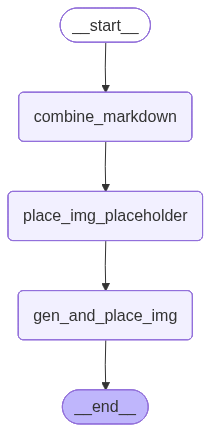

In [246]:
sub_workflow

In [253]:
graph = StateGraph(main_state)

graph.add_node('research',research)
graph.add_node('router',router)
graph.add_node('orc',orc)
graph.add_node('worker',worker)

graph.add_node("reducer", sub_workflow)




graph.add_edge(START,'router')
graph.add_conditional_edges('router',router_next,{True:'research',False: 'orc'})
graph.add_edge('research','orc')

graph.add_conditional_edges('orc',fan_out,['worker'])
graph.add_edge('worker','reducer')
graph.add_edge('reducer',END)



workflow = graph.compile()

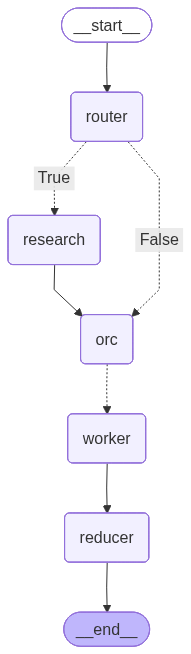

In [248]:
workflow

In [249]:
initial ={
            "topic": 'self attention',
            "needs_research": False,
            "queries": [],
            "plan": None,
            "sections": [],
            "merged_md": "",
            "md_with_placeholders": "",
            "image_specs": [],
            "final_blog": "",
        }

In [250]:
config = {'configurable':{'thread_id':'thread-1'}}
res = workflow.invoke(initial,config=config)

c:\Users\sajid\OneDrive\Desktop\Blog\NewEnv\Lib\site-packages\pydantic\json_schema.py:2448: PydanticJsonSchemaWarning: Default value typing.Literal['True', 'False'] is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


In [251]:
res

{'topic': 'self attention',
 'needs_research': False,
 'research_mode': 'closed_book',
 'queries': [],
 'plan': Plan(main_blog_title='Self-Attention Explained: How Transformers Weigh Relationships in a Sequence', audience='Beginners to intermediate ML practitioners learning Transformers (including students, junior engineers, and product ML developers)', tone='Educational, technical but approachable', blog_kind='explainer', blog_sections=[section(section_id=1, section_title='What Self-Attention Solves (and Why It Beats RNNs for Context)', target_length=95, requires_code=False, section_description='Explain the core problem self-attention addresses: capturing long-range dependencies and contextual meaning within a sequence. Answer: What is the limitation of RNNs/seq2seq (path length, sequential bottlenecks)? What does “contextualize tokens” mean? Introduce the high-level idea: each token computes how much it should attend to every other token. Include a concrete toy example (e.g., interpr

In [252]:
workflow.get_state(config).values['plan'].main_blog_title

Deserializing unregistered type __main__.Plan from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Plan')]


'Self-Attention Explained: How Transformers Weigh Relationships in a Sequence'